# VEP Penetrance
Tests for a relationship between VEP and population-derived penetrance.


- Test variance within diseases (within variants) of VEP vs penetrance
- Test variace across populations of VEP vs penetrance

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.onekg as og

pd.set_option('display.max_columns', None)

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [18]:
pop_freqs = hs.get_haplotype_freqs(haplotypes, return_df=True)
pop_freqs.head()

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Adding top superpopulation

Number of variants specific to each population:
specific_superpopulation
1000GENOMES:phase_3:AFR    7
1000GENOMES:phase_3:EUR    6
1000GENOMES:phase_3:EAS    2
1000GENOMES:phase_3:SAS    2
1000GENOMES:phase_3:AMR    1
Name: count, dtype: int64

Percentage of population-specific haplotypes: 94.74%


,ENST,haplotype,freq_1000GENOMES:phase_3:SAS,freq_1000GENOMES:phase_3:IBS,freq_1000GENOMES:phase_3:GIH,freq_1000GENOMES:phase_3:PJL,freq_1000GENOMES:phase_3:MXL,freq_1000GENOMES:phase_3:TSI,freq_1000GENOMES:phase_3:AMR,freq_1000GENOMES:phase_3:PEL,freq_GGVP:GWJ,freq_1000GENOMES:phase_3:LWK,freq_GGVP:GWF,freq_GGVP:GWD,freq_1000GENOMES:phase_3:ACB,freq_all,freq_1000GENOMES:phase_3:AFR,freq_1000GENOMES:phase_3:ASW,freq_1000GENOMES:phase_3:PUR,freq_1000GENOMES:phase_3:EUR,freq_1000GENOMES:phase_3:JPT,freq_GGVP:ALL,freq_1000GENOMES:phase_3:ITU,freq_1000GENOMES:phase_3:MSL,freq_1000GENOMES:phase_3:ESN,freq_1000GENOMES:phase_3:ALL,freq_1000GENOMES:phase_3:GWD,freq_1000GENOMES:phase_3:CHS,freq_1000GENOMES:phase_3:GBR,freq_1000GENOMES:phase_3:YRI,freq_1000GENOMES:phase_3:CLM,freq_1000GENOMES:phase_3:CHB,freq_1000GENOMES:phase_3:FIN,freq_1000GENOMES:phase_3:CEU,freq_GGVP:GWW,freq_1000GENOMES:phase_3:EAS,freq_1000GENOMES:phase_3:CDX,freq_1000GENOMES:phase_3:KHV,freq_1000GENOMES:phase_3:BEB,freq_1000GENOMES:phase_3:STU,top_pop,top_superpop,top_superpop_freq,nonzero_superpop_freqs,specific_superpopulation
0,ENST00000304992,ENSP00000304350:REF,0.997955,0.995327,1,0.989583,1,1,0.998559,0.994118,1,1,1,1,0.989583,0.997009,0.994705,1,1,0.994036,1,1,1,0.994118,0.984848,0.996406,1,0.990476,0.983516,0.99537,1,1,0.994949,0.994949,1,0.998016,1,1,1,1,1000GENOMES:phase_3:GIH,freq_1000GENOMES:phase_3:AMR,0.998559,5,None
1,ENST00000304992,ENSP00000304350:1121N>D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000166,NaN,NaN,NaN,0.000994,NaN,NaN,NaN,NaN,NaN,0.0002,NaN,NaN,0.005495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000GENOMES:phase_3:GBR,freq_1000GENOMES:phase_3:EUR,0.000994,1,1000GENOMES:phase_3:EUR
2,ENST00000304992,ENSP00000304350:1235E>D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000166,NaN,NaN,NaN,0.000994,NaN,NaN,NaN,NaN,NaN,0.0002,NaN,NaN,NaN,NaN,NaN,NaN,0.005051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000GENOMES:phase_3:FIN,freq_1000GENOMES:phase_3:EUR,0.000994,1,1000GENOMES:phase_3:EUR
3,ENST00000304992,ENSP00000304350:129V>I,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000166,0.000756,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005051,0.0002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000GENOMES:phase_3:ESN,freq_1000GENOMES:phase_3:AFR,0.000756,1,1000GENOMES:phase_3:AFR
4,ENST00000304992,ENSP00000304350:1330M>V,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000166,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0002,NaN,0.004762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000992,NaN,NaN,NaN,NaN,1000GENOMES:phase_3:CHS,freq_1000GENOMES:phase_3:EAS,0.000992,1,1000GENOMES:phase_3:EAS


In [3]:
vep_files = va.list_vep_files(as_df=True)
vep_files.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/3 [00:00<?, ?it/s]

Found 681511 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 7
scoring_strategy: 3
variant_set: 1
haplotype: 85106
protein: 2142


,file,protein,haplotype,variant_set,model_location,scoring_strategy
0,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
1,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
2,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:914L>V,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
3,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:793S>I,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
4,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:1106V>A,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals


In [4]:
vep_df = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[vep_files['model_location']=="esm2_t33_650M_UR50D"]
    )
vep_df["rsID"] = "rs" + vep_df["RS"].fillna(0).round().astype(int).astype(str)

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 57984 masked-marginals parquet files


Reading files:   0%|          | 0/57984 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Forrest2020

https://jamanetwork.com/journals/jama/fullarticle/10.1001/jama.2021.23686?utm_campaign=articlePDF%26utm_medium=articlePDFlink%26utm_source=articlePDF%26utm_content=jama.2021.23686

> The complete penetrance dataset with 7,618 variants from BioBioMe and 31,478
variants from UK Biobank used for all analyses is provided
(https://data.mendeley.com/datasets/v37dmjkbfj/draft?a=a2f58e92-da19-461d-991a-46dc70128860) with no restrictions on the data released.

In [5]:
biome = pd.read_excel("../data/Forrest2020/Forrest_Penetrance_PenetranceDataset.xlsx", 
                      sheet_name="BioMe")
ukb = pd.read_excel("../data/Forrest2020/Forrest_Penetrance_PenetranceDataset.xlsx", 
                      sheet_name="UKB")

In [7]:
pene = ukb

In [12]:
penetrance_cols = [col for col in pene.columns if col.lower().endswith('_penetrance')]
penetrance_pops = set(col.split("_")[1] for col in penetrance_cols)
penetrance_pops

# Calculate mean RD for each population
for pop in penetrance_pops: 
    pop_cols = [col for col in pene.columns if f"{pop}_Penetrance" in col]
    # Compute mean RD for this pop
    pene[f'penetrance_{pop}_mean'] = pene[pop_cols].mean(axis=1, skipna=True)
    pene[f'penetrance_{pop}_var'] = pene[pop_cols].var(axis=1, skipna=True)

pene.head()

,Variant,CHR,POS,REF,ALT,rsID,ClinVar_Summary,Consequence,RefSeq_Gene,ClinVar_Classification,ClinVar_ReviewStatus,ClinVar_NumberSubmitters,Disease,OMIM_Gene,OMIM_Inheritance,Pathogenic_LoF,Affected_Carriers,Total_Carriers,Penetrance,Affected_Noncarriers,Total_Noncarriers,Disease_Prevalence_Noncarriers,RD,40yo_EUR_Affected_Carriers,40yo_EUR_Total_Carriers,40yo_EUR_Penetrance,50yo_EUR_Affected_Carriers,50yo_EUR_Total_Carriers,50yo_EUR_Penetrance,60yo_EUR_Affected_Carriers,60yo_EUR_Total_Carriers,60yo_EUR_Penetrance,40yo_MIX_Affected_Carriers,40yo_MIX_Total_Carriers,40yo_MIX_Penetrance,50yo_MIX_Affected_Carriers,50yo_MIX_Total_Carriers,50yo_MIX_Penetrance,60yo_MIX_Affected_Carriers,60yo_MIX_Total_Carriers,60yo_MIX_Penetrance,40yo_ASA_Affected_Carriers,40yo_ASA_Total_Carriers,40yo_ASA_Penetrance,50yo_ASA_Affected_Carriers,50yo_ASA_Total_Carriers,50yo_ASA_Penetrance,60yo_ASA_Affected_Carriers,60yo_ASA_Total_Carriers,60yo_ASA_Penetrance,40yo_AFR_Affected_Carriers,40yo_AFR_Total_Carriers,40yo_AFR_Penetrance,50yo_AFR_Affected_Carriers,50yo_AFR_Total_Carriers,50yo_AFR_Penetrance,60yo_AFR_Affected_Carriers,60yo_AFR_Total_Carriers,60yo_AFR_Penetrance,penetrance_MIX,penetrance_ASA,penetrance_AFR,penetrance_EUR,penetrance_MIX_mean,penetrance_MIX_var,penetrance_ASA_mean,penetrance_ASA_var,penetrance_AFR_mean,penetrance_AFR_var,penetrance_EUR_mean,penetrance_EUR_var
0,4.1799344.G.A_A,4,1799344,G,A,rs369232922,NM_000142.4(FGFR3):c.200G>A (p.Gly67Asp),missense_variant,FGFR3,Uncertain_significance,"criteria_provided,_multiple_submitters,_no_con...",2.0,Achondroplasia,FGFR3,Conflicting,False,0,4,0.0,17,43391,0.039179,-0.000392,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,0.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,NaN
1,4.1804404.T.C_C,4,1804404,T,C,rs17881656,NM_000142.4(FGFR3):c.1150T>C (p.Phe384Leu),missense_variant,FGFR3,Benign/Likely_benign,"criteria_provided,_multiple_submitters,_no_con...",8.0,Achondroplasia,FGFR3,Conflicting,False,0,457,0.0,17,42938,0.039592,-0.000396,0.0,450.0,0.0,0.0,354.0,0.0,0.0,207.0,0.0,0.0,3.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.1804902.C.T_T,4,1804902,C,T,rs61735104,NM_000142.4(FGFR3):c.1345C>T (p.Pro449Ser),missense_variant,FGFR3,Benign/Likely_benign,"criteria_provided,_multiple_submitters,_no_con...",8.0,Achondroplasia,FGFR3,Conflicting,False,0,442,0.0,17,42953,0.039578,-0.000396,0.0,437.0,0.0,0.0,347.0,0.0,0.0,193.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,0.0,3.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0
3,4.1805636.A.G_G,4,1805636,A,G,rs80053154,NM_000142.4(FGFR3):c.1612A>G (p.Ile538Val),missense_variant,FGFR3,Pathogenic,no_assertion_criteria_provided,2.0,Achondroplasia,FGFR3,Conflicting,True,0,3,0.0,17,43392,0.039178,-0.000392,0.0,3.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,4.1805643.A.G_G,4,1805643,A,G,rs77722678,NM_000142.4(FGFR3):c.1619A>G (p.Asn540Ser),missense_variant,FGFR3,Uncertain_significance,"criteria_provided,_single_submitter",3.0,Achondroplasia,FGFR3,Conflicting,False,0,3,0.0,17,43392,0.039178,-0.000392,0.0,3.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0


In [ ]:
within_site_var, within_site_var_mean = va.get_mondo_within_site_var(
    vep_df=vep_df,
    groupby_cols= ["model_location",
                    "protein",
                    "ENSP","GENEINFO",
                    "clinsig",
                    "RS",   
                    "mutant",
                    "scoring_strategy"]
                    )
within_site_var["rsID"] = "rs" + within_site_var["RS"].fillna(0).round().astype(int).astype(str)
within_site_var.head()

,MONDO,MONDO_split,model_location,clinsig,protein,ENSP,GENEINFO,RS,mutant,scoring_strategy,VEP,haplotype,MONDO_label,rsID
31588,MONDO:0060760,MONDO:0060760,esm2_t33_650M_UR50D,likely_path,NP_001177203.1,ENSP00000384823,FBXO11:80204,1671184211,G665R,masked-marginals,33.686699,17,intellectual developmental disorder with dysmo...,rs1671184211
11662,MONDO:0010091,MONDO:0010091,esm2_t33_650M_UR50D,likely_path,NP_004741.1,ENSP00000376188,CRLF1:9244,137853933,R312L,masked-marginals,29.220486,23,Cold-induced sweating syndrome 1,rs137853933
15853,MONDO:0011871|MONDO:0009756,MONDO:0009756,esm2_t33_650M_UR50D,likely_path,NP_000534.3,ENSP00000340409,SMPD1:6609,398123475,C433W,masked-marginals,29.179911,101,Niemann-Pick disease type A,rs398123475
15885,MONDO:0011871|MONDO:0009756,MONDO:0011871,esm2_t33_650M_UR50D,likely_path,NP_000534.3,ENSP00000340409,SMPD1:6609,398123475,C433W,masked-marginals,29.179911,101,Niemann-Pick disease type B,rs398123475
653,MONDO:0001982|MONDO:0011871,MONDO:0011871,esm2_t33_650M_UR50D,likely_path,NP_000534.3,ENSP00000340409,SMPD1:6609,797044797,L139P,masked-marginals,28.700430,101,Niemann-Pick disease type B,rs797044797


In [15]:
print(len(utils.intersect(within_site_var["rsID"], biome["rsID"])))
print(len(utils.intersect(within_site_var["rsID"], ukb["rsID"])))

60
966


### Merge at the disease level

In [25]:
import src.owlready2 as OWL

onto = OWL.get_onto_mondo()

In [68]:
from tqdm import tqdm

# Get the first MONDO ID from the map
icd10_dict = {}

for id in tqdm(within_site_var_mean["MONDO_split"].unique()):
    # Get the corresponding OWL object
    obj = onto.search_one(iri=OWL.process_id(id))
    # Get cross-referenced ICD-10 IDs
    icd10_dict[id] = [ref for ref in obj.hasDbXref if ref.startswith('ICD10')]
    

100%|██████████| 2688/2688 [00:54<00:00, 49.59it/s]


In [48]:
within_site_var_mean.loc[:, "ICD10"] = within_site_var_mean["MONDO_split"].map(icd10_dict)
within_site_var_mean =  within_site_var_mean.explode("ICD10")

In [57]:
print(within_site_var_mean["MONDO_label"].nunique())
print(pene["Disease"].nunique())


2688
142


In [59]:
icdo = OWL.get_onto_icdo()

SHA256 hash of downloaded file: 1e20c40d97bbeae1531a063632f948c4c2617eb72e097904a5a861e8bf67bae4
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


In [90]:
icd10_codes = OWL.get_icd10_codes()
print(icd10_codes.shape)
icd10_codes.head()

(72184, 2)


,code,label
0,A000,"Cholera due to Vibrio cholerae 01, biovar chol..."
1,A001,"Cholera due to Vibrio cholerae 01, biovar eltor"
2,A009,"Cholera, unspecified"
3,A0100,"Typhoid fever, unspecified"
4,A0101,Typhoid meningitis


In [92]:
pene.merge(icd10_codes, left_on="Disease", right_on="label", how="inner")

,Variant,CHR,POS,REF,ALT,rsID,ClinVar_Summary,Consequence,RefSeq_Gene,ClinVar_Classification,ClinVar_ReviewStatus,ClinVar_NumberSubmitters,Disease,OMIM_Gene,OMIM_Inheritance,Pathogenic_LoF,Affected_Carriers,Total_Carriers,Penetrance,Affected_Noncarriers,Total_Noncarriers,Disease_Prevalence_Noncarriers,RD,40yo_EUR_Affected_Carriers,40yo_EUR_Total_Carriers,40yo_EUR_Penetrance,50yo_EUR_Affected_Carriers,50yo_EUR_Total_Carriers,50yo_EUR_Penetrance,60yo_EUR_Affected_Carriers,60yo_EUR_Total_Carriers,60yo_EUR_Penetrance,40yo_MIX_Affected_Carriers,40yo_MIX_Total_Carriers,40yo_MIX_Penetrance,50yo_MIX_Affected_Carriers,50yo_MIX_Total_Carriers,50yo_MIX_Penetrance,60yo_MIX_Affected_Carriers,60yo_MIX_Total_Carriers,60yo_MIX_Penetrance,40yo_ASA_Affected_Carriers,40yo_ASA_Total_Carriers,40yo_ASA_Penetrance,50yo_ASA_Affected_Carriers,50yo_ASA_Total_Carriers,50yo_ASA_Penetrance,60yo_ASA_Affected_Carriers,60yo_ASA_Total_Carriers,60yo_ASA_Penetrance,40yo_AFR_Affected_Carriers,40yo_AFR_Total_Carriers,40yo_AFR_Penetrance,50yo_AFR_Affected_Carriers,50yo_AFR_Total_Carriers,50yo_AFR_Penetrance,60yo_AFR_Affected_Carriers,60yo_AFR_Total_Carriers,60yo_AFR_Penetrance,penetrance_MIX,penetrance_ASA,penetrance_AFR,penetrance_EUR,penetrance_MIX_mean,penetrance_MIX_var,penetrance_ASA_mean,penetrance_ASA_var,penetrance_AFR_mean,penetrance_AFR_var,penetrance_EUR_mean,penetrance_EUR_var,code,label
0,4.1799344.G.A_A,4,1799344,G,A,rs369232922,NM_000142.4(FGFR3):c.200G>A (p.Gly67Asp),missense_variant,FGFR3,Uncertain_significance,"criteria_provided,_multiple_submitters,_no_con...",2.0,Achondroplasia,FGFR3,Conflicting,False,0,4,0.0,17,43391,0.039179,-0.000392,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,0.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,NaN,Q774,Achondroplasia
1,4.1804404.T.C_C,4,1804404,T,C,rs17881656,NM_000142.4(FGFR3):c.1150T>C (p.Phe384Leu),missense_variant,FGFR3,Benign/Likely_benign,"criteria_provided,_multiple_submitters,_no_con...",8.0,Achondroplasia,FGFR3,Conflicting,False,0,457,0.0,17,42938,0.039592,-0.000396,0.0,450.0,0.0,0.0,354.0,0.0,0.0,207.0,0.0,0.0,3.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Q774,Achondroplasia
2,4.1804902.C.T_T,4,1804902,C,T,rs61735104,NM_000142.4(FGFR3):c.1345C>T (p.Pro449Ser),missense_variant,FGFR3,Benign/Likely_benign,"criteria_provided,_multiple_submitters,_no_con...",8.0,Achondroplasia,FGFR3,Conflicting,False,0,442,0.0,17,42953,0.039578,-0.000396,0.0,437.0,0.0,0.0,347.0,0.0,0.0,193.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,0.0,3.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,Q774,Achondroplasia
3,4.1805636.A.G_G,4,1805636,A,G,rs80053154,NM_000142.4(FGFR3):c.1612A>G (p.Ile538Val),missense_variant,FGFR3,Pathogenic,no_assertion_criteria_provided,2.0,Achondroplasia,FGFR3,Conflicting,True,0,3,0.0,17,43392,0.039178,-0.000392,0.0,3.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,Q774,Achondroplasia
4,4.1805643.A.G_G,4,1805643,A,G,rs77722678,NM_000142.4(FGFR3):c.1619A>G (p.Asn540Ser),missense_variant,FGFR3,Uncertain_significance,"criteria_provided,_single_submitter",3.0,Achondroplasia,FGFR3,Conflicting,False,0,3,0.0,17,43392,0.039178,-0.000392,0.0,3.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,Q774,Achondroplasia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [55]:
utils.intersect(within_site_var_mean["MONDO_label"].str.lower(), 
                pene["Disease"].str.lower())

['familial renal glucosuria',
 'maturity-onset diabetes of the young',
 'postmenopausal osteoporosis',
 'familial restrictive cardiomyopathy',
 'frontotemporal dementia',
 'danon disease',
 'emery-dreifuss muscular dystrophy',
 'cardiomyopathy',
 'beta thalassemia',
 'crouzon syndrome',
 'endometrial carcinoma',
 'achondroplasia',
 'nephrogenic diabetes insipidus',
 'familial porphyria cutanea tarda',
 'neonatal diabetes mellitus',
 'myofibrillar myopathy',
 'age-related macular degeneration',
 'ovarian hyperstimulation syndrome',
 'muir-torre syndrome',
 'choroideremia',
 'brugada syndrome',
 'aplastic anemia',
 'lipoprotein glomerulopathy',
 'hepatocellular carcinoma',
 'neurohypophyseal diabetes insipidus',
 'arrhythmogenic right ventricular cardiomyopathy']

In [16]:
# Import haplotypes if not already defined
if 'haplotypes' not in locals():
    haplotypes = hs.get_haplotypes(
        tx_ids=vep_df['ENST'].unique().tolist(),
        cache_only=True
    )

# Add haplotype sequences to the VEP dataframe
vep_df = va.add_mutant_out_of_frame(vep_df, 
                                    haplotypes=haplotypes,
                                    force=True)


# haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes, 
#                                            as_df=True,
#                                            add_sample_metadata=True,
#                                            return_seqs=False) 

Found haplotypes of 47325 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes:   0%|          | 0/1450 [00:00<?, ?it/s]

Adding 'haplotype_sequence' column
Getting haplotype sequences


Adding reference haplotype:   0%|          | 0/1450 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/1450 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1450 [00:00<?, ?it/s]

Adding 'haplotype_sequence' column
Adding 'haplotype_sequence_len' column
Adding 'mutant_out_of_frame' column


In [70]:
pop_freqs = hs.get_haplotype_freqs(haplotypes=haplotypes,
                                   return_df=True) 
pop_freqs.head()

Getting haplotype frequencies:   0%|          | 0/1450 [00:00<?, ?it/s]

Adding top superpopulation

Number of variants specific to each population:
specific_superpopulation
1000GENOMES:phase_3:AFR    14374
1000GENOMES:phase_3:EAS     9624
1000GENOMES:phase_3:SAS     8993
1000GENOMES:phase_3:EUR     6757
1000GENOMES:phase_3:AMR     4774
Name: count, dtype: int64

Percentage of population-specific haplotypes: 76.60%


,ENST,haplotype,freq_1000GENOMES:phase_3:ASW,freq_all,freq_1000GENOMES:phase_3:EAS,freq_1000GENOMES:phase_3:PEL,freq_1000GENOMES:phase_3:LWK,freq_1000GENOMES:phase_3:KHV,freq_GGVP:GWJ,freq_1000GENOMES:phase_3:CHS,freq_1000GENOMES:phase_3:CEU,freq_GGVP:GWF,freq_1000GENOMES:phase_3:MSL,freq_1000GENOMES:phase_3:BEB,freq_1000GENOMES:phase_3:ESN,freq_1000GENOMES:phase_3:CHB,freq_1000GENOMES:phase_3:IBS,freq_GGVP:GWD,freq_1000GENOMES:phase_3:PUR,freq_1000GENOMES:phase_3:ITU,freq_GGVP:GWW,freq_1000GENOMES:phase_3:CLM,freq_1000GENOMES:phase_3:GWD,freq_1000GENOMES:phase_3:GBR,freq_1000GENOMES:phase_3:CDX,freq_1000GENOMES:phase_3:STU,freq_1000GENOMES:phase_3:GIH,freq_1000GENOMES:phase_3:TSI,freq_1000GENOMES:phase_3:SAS,freq_1000GENOMES:phase_3:EUR,freq_1000GENOMES:phase_3:PJL,freq_1000GENOMES:phase_3:AMR,freq_1000GENOMES:phase_3:FIN,freq_1000GENOMES:phase_3:ACB,freq_1000GENOMES:phase_3:AFR,freq_1000GENOMES:phase_3:MXL,freq_1000GENOMES:phase_3:YRI,freq_1000GENOMES:phase_3:ALL,freq_1000GENOMES:phase_3:JPT,freq_GGVP:ALL,top_pop,top_superpop,top_superpop_freq,nonzero_superpop_freqs,specific_superpopulation
0,ENST00000001146,ENSP00000001146:REF,0.57377,0.7554,0.875992,0.717647,0.570707,0.909091,0.581633,0.885714,0.818182,0.586957,0.570588,0.906977,0.691919,0.878641,0.836449,0.580645,0.8125,0.921569,0.602041,0.87234,0.597345,0.802198,0.897849,0.862745,0.873786,0.864486,0.897751,0.833996,0.927083,0.783862,0.843434,0.65625,0.612708,0.695312,0.611111,0.789537,0.8125,0.586139,1000GENOMES:phase_3:PJL,freq_1000GENOMES:phase_3:SAS,0.897751,5,None
1,ENST00000001146,ENSP00000001146:264L>S,0.278689,0.191758,0.074405,0.282353,0.318182,0.055556,0.290816,0.07619,0.181818,0.336957,0.317647,0.081395,0.20202,0.082524,0.163551,0.31106,0.168269,0.068627,0.311224,0.12234,0.336283,0.197802,0.080645,0.132353,0.121359,0.135514,0.095092,0.16501,0.067708,0.206052,0.151515,0.203125,0.273828,0.289062,0.259259,0.167532,0.076923,0.311881,GGVP:GWF,freq_1000GENOMES:phase_3:AFR,0.273828,5,None
2,ENST00000001146,ENSP00000001146:420A>G,0.090164,0.019276,NaN,NaN,0.030303,NaN,0.056122,NaN,NaN,0.016304,0.047059,NaN,0.050505,NaN,NaN,0.0553,0.004808,NaN,0.045918,NaN,0.035398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001441,NaN,0.0625,0.051437,NaN,0.060185,0.013778,NaN,0.046535,1000GENOMES:phase_3:ASW,freq_1000GENOMES:phase_3:AFR,0.051437,2,None
3,ENST00000001146,ENSP00000001146:473R>C,0.040984,0.006481,NaN,NaN,0.010101,NaN,NaN,NaN,NaN,0.01087,0.029412,NaN,0.020202,NaN,NaN,0.011521,0.009615,NaN,0.015306,NaN,0.004425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002882,NaN,0.020833,0.020424,NaN,0.027778,0.005791,NaN,0.009901,1000GENOMES:phase_3:ASW,freq_1000GENOMES:phase_3:AFR,0.020424,2,None
4,ENST00000001146,"ENSP00000001146:22V>L,264L>S",NaN,0.004653,NaN,NaN,0.015152,NaN,0.030612,NaN,NaN,0.016304,0.017647,NaN,NaN,NaN,NaN,0.016129,NaN,NaN,NaN,NaN,0.004425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.015625,0.009077,NaN,0.009259,0.002396,NaN,0.015842,GGVP:GWJ,freq_1000GENOMES:phase_3:AFR,0.009077,1,1000GENOMES:phase_3:AFR


In [78]:
freq_cols=["freq_1000GENOMES:phase_3:ALL","top_pop","top_superpop","top_superpop_freq","nonzero_superpop_freqs","specific_superpopulation"]
# Drop any existing frequency columns from vep_df
vep_df = vep_df.loc[:, ~vep_df.columns.str.startswith(tuple(freq_cols))]
# Merge with new frequency data
vep_df = vep_df.merge(pop_freqs.loc[:,["haplotype"]+freq_cols], on="haplotype", how="left")
vep_df.head()

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,MONDO,MONDO_n,MONDO_split,freq_1000GENOMES:phase_3:ALL,top_pop,top_superpop,top_superpop_freq,nonzero_superpop_freqs,specific_superpopulation
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025,NaN,ClinGen:CA008015,NaN,NaN,NaN,NaN,NaN,-6.731237,-0.021689,6,benign,MONDO:0019171|MONDO:0002442|MONDO:0016587|MOND...,4,"[MONDO:0019171, MONDO:0002442, MONDO:0016587, ...",0.0002,1000GENOMES:phase_3:KHV,freq_1000GENOMES:phase_3:EAS,0.000992,1.0,1000GENOMES:phase_3:EAS
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402,NaN,ClinGen:CA007791,NaN,NaN,NaN,NaN,NaN,-2.509515,-0.039753,6,likely_path,,0,[],0.0002,1000GENOMES:phase_3:KHV,freq_1000GENOMES:phase_3:EAS,0.000992,1.0,1000GENOMES:phase_3:EAS
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,NaN,NaN,NaN,NaN,NaN,-5.869637,-0.057342,6,likely_path,MONDO:0019171|MONDO:0013367,2,"[MONDO:0019171, MONDO:0013367]",0.0002,1000GENOMES:phase_3:KHV,freq_1000GENOMES:phase_3:EAS,0.000992,1.0,1000GENOMES:phase_3:EAS
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVEN

In [153]:
weighted_var= vep_df.groupby(["model_location","scoring_strategy","top_superpop",
                              "clinsig","protein","ENSP","GENEINFO","RS","mutant"]
                              ).apply(lambda x: va.weighted_variance(x["VEP"], x["freq_1000GENOMES:phase_3:ALL"])).reset_index(name="weighted_var")


from sklearn.preprocessing import RobustScaler

# Group the data
grouped = weighted_var.groupby(["model_location","scoring_strategy","top_superpop",
                      "protein","ENSP","GENEINFO"])

# Apply RobustScaler to normalize within each group
# scaler = RobustScaler()
# weighted_var['weighted_var_normalized'] = grouped['weighted_var'].transform(
#     lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).ravel()
# )
weighted_var["rsID"] = "rs" + weighted_var["RS"].fillna(0).round().astype(int).astype(str)

/tmp/ipykernel_1462029/1116385234.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(lambda x: weighted_variance(x["VEP"], x["freq_1000GENOMES:phase_3:ALL"])).reset_index(name="weighted_var")
/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:1642: RuntimeWarning: All-NaN slice encountered
  self.center_ = np.nanmedian(X, axis=0)
/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1409: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:1642: RuntimeWarning: All-NaN slice encountered
  self.ce

In [149]:
rmerge = vep_df.merge(pene, 
                      on="rsID", how="inner")

# rmerge = weighted_var.merge(pene, 
#                               on="rsID", how="inner")

print(rmerge.shape)
rmerge.head()  

(134404, 151)


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS_x,ID,REF_x,ALT_x,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence_x,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,MONDO,MONDO_n,MONDO_split,haplotype_sequence,reference_sequence_len,haplotype_sequence_len,haplotype_sequence_len_pct,mutant_out_of_frame,rsID,Variant,CHR,POS_y,REF_y,ALT_y,ClinVar_Summary,Consequence_y,RefSeq_Gene,ClinVar_Classification,ClinVar_ReviewStatus,ClinVar_NumberSubmitters,Disease,OMIM_Gene,OMIM_Inheritance,Pathogenic_LoF,Affected_Carriers,Total_Carriers,Penetrance,Affected_Noncarriers,Total_Noncarriers,Disease_Prevalence_Noncarriers,RD,40yo_EUR_Affected_Carriers,40yo_EUR_Total_Carriers,40yo_EUR_Penetrance,50yo_EUR_Affected_Carriers,50yo_EUR_Total_Carriers,50yo_EUR_Penetrance,60yo_EUR_Affected_Carriers,60yo_EUR_Total_Carriers,60yo_EUR_Penetrance,40yo_MIX_Affected_Carriers,40yo_MIX_Total_Carriers,40yo_MIX_Penetrance,50yo_MIX_Affected_Carriers,50yo_MIX_Total_Carriers,50yo_MIX_Penetrance,60yo_MIX_Affected_Carriers,60yo_MIX_Total_Carriers,60yo_MIX_Penetrance,40yo_ASA_Affected_Carriers,40yo_ASA_Total_Carriers,40yo_ASA_Penetrance,50yo_ASA_Affected_Carriers,50yo_ASA_Total_Carriers,50yo_ASA_Penetrance,60yo_ASA_Affected_Carriers,60yo_ASA_Total_Carriers,60yo_ASA_Penetrance,40yo_AFR_Affected_Carriers,40yo_AFR_Total_Carriers,40yo_AFR_Penetrance,50yo_AFR_Affected_Carriers,50yo_AFR_Total_Carriers,50yo_AFR_Penetrance,60yo_AFR_Affected_Carriers,60yo_AFR_Total_Carriers,60yo_AFR_Penetrance,penetrance_MIX,penetrance_ASA,penetrance_AFR,penetrance_EUR,penetrance_MIX_mean,penetrance_MIX_var,penetrance_ASA_mean,penetrance_ASA_var,penetrance_AFR_mean,penetrance_AFR_var,penetrance_EUR_mean,penetrance_EUR_var
0,ENSP00000333994:109N>H,NP_000509.1,MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,H144Y,MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,Benign,-3.138461,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000333994,ENST00000335295,False,11,5225612,15565,G,A,.,PASS,15565,11:5225612,A,3043,NM_000518.5,Transcript,missense_variant,480,430,144,H/Y,Cac/Tac,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000518.5:c.430C>T,NP_000509.1:p.His144Tyr,-,NaN,0.00001,30604,MedGen:CN169374|MedGen:CN517202,not_specified|not_provided,NC_000011.10:g.5225612G>A,"criteria_provided,_multiple_submitters,_no_con...",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,HBB:3043|LOC107133510:107133510|LOC110006319:1...,SO:0001583|missense_variant,1,33929415,NaN,ClinGen:CA125454|HBVAR:566|OMIM:141900.0477,NaN,NaN,NaN,-4.498498,-2.750882,-2.319881,-0.077086,9,likely_benign,,0,[],MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,147,147.0,1.0,False,rs33929415,11.5225612.G.A_A,11,5225612,G,A,NM_000518.4(HBB):c.430C>T (p.His144Tyr),missense_variant,HBB,Benign,no_assertion_criteria_provided,1.0,alpha Thalassemia,HBB,Conflicting,False,0,2,0.0,2,43393,0.004609,-0.000046,0.0,2.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,ENSP00000333994:109N>H,NP_000509.1,MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,H144Y,MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,Benign,-3.138461,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000333994,ENST00000335295,False,11,5225612,15565,G,A,.,PASS,15565,11:5225612,A,3043,NM_000518.5,Transcript,missense_variant,480,430,144,H/Y,Cac/Tac,-,MODERATE,-,-

<Axes: xlabel='VEP', ylabel='RD'>

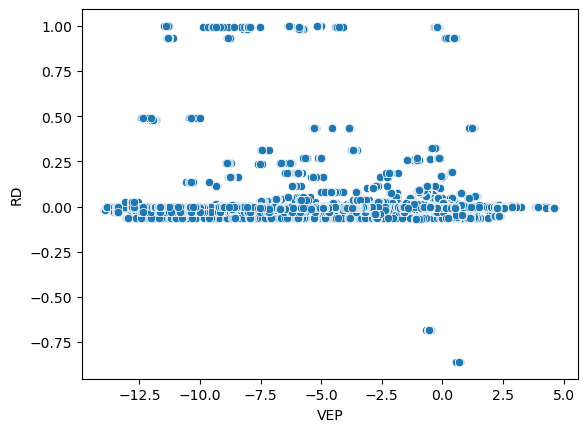

In [150]:
sns.scatterplot(data=rmerge, x="VEP", y="RD")

In [143]:
rmerge_var = rmerge.groupby(["model_location","scoring_strategy","MONDO","clinsig"]
                            ).agg({"VEP": "var", "RD": "mean"}).reset_index()

rmerge_var.shape

(643, 6)

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


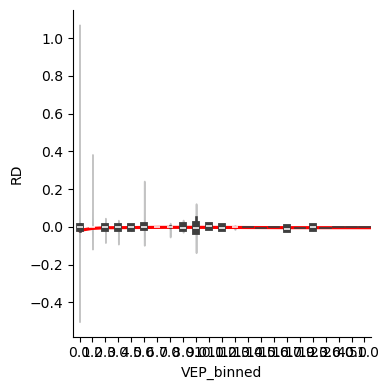

In [155]:
import seaborn as sns
import numpy as np
rmerge_var["log_RD"] = np.log(rmerge_var["RD"])
rmerge_var["log_VEP"] = np.log(rmerge_var["VEP"]) 
rmerge_var["VEP_binned"] = rmerge_var["VEP"].round()

# Create a FacetGrid with CLNSIG as the facet variable
g = sns.FacetGrid(rmerge_var, 
                #   col="clinsig", 
                #   col_wrap=4,
                    height=4)

# Add regression line and scatter plot to each facet
g.map_dataframe(sns.regplot, x="VEP_binned", y="RD", 
                scatter=False,  
                lowess=True, 
                line_kws={'color': 'red'})
g.map_dataframe(sns.violinplot, x="VEP_binned", y="RD", alpha=0.3)

# Adjust layout
g.fig.tight_layout()

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:__main__:Processing population: freq_1000GENOMES:phase_3:AFR
INFO:__main__:Processing population: freq_1000GENOMES:phase_3:AMR
INFO:__main__:Processing population: freq_1000GENOMES:phase_3:EAS
INFO:__main__:Processing population: freq_1000GENOMES:phase_3:EUR
INFO:__main__:Processing population: freq_1000GENOMES:phase_3:SAS


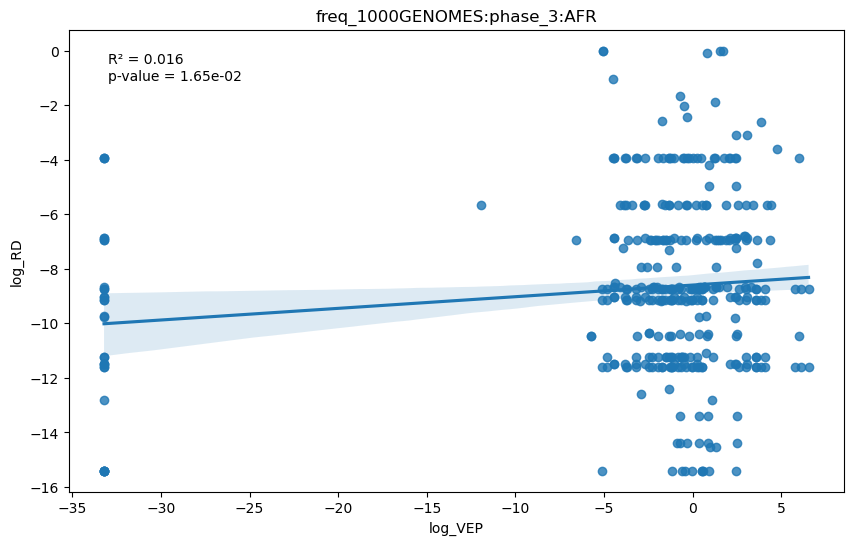

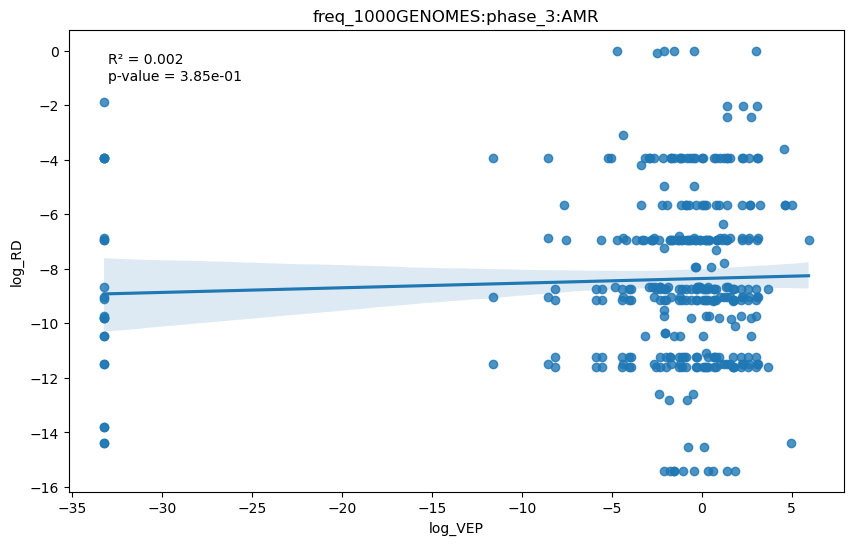

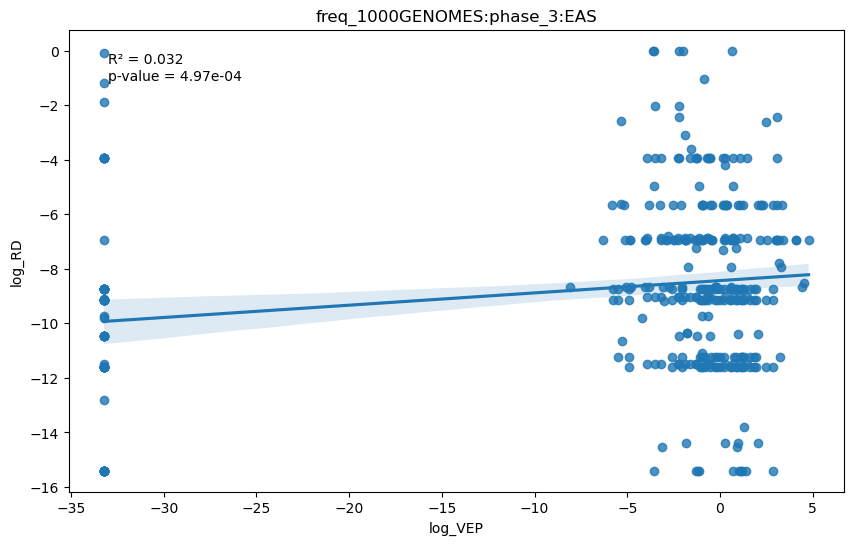

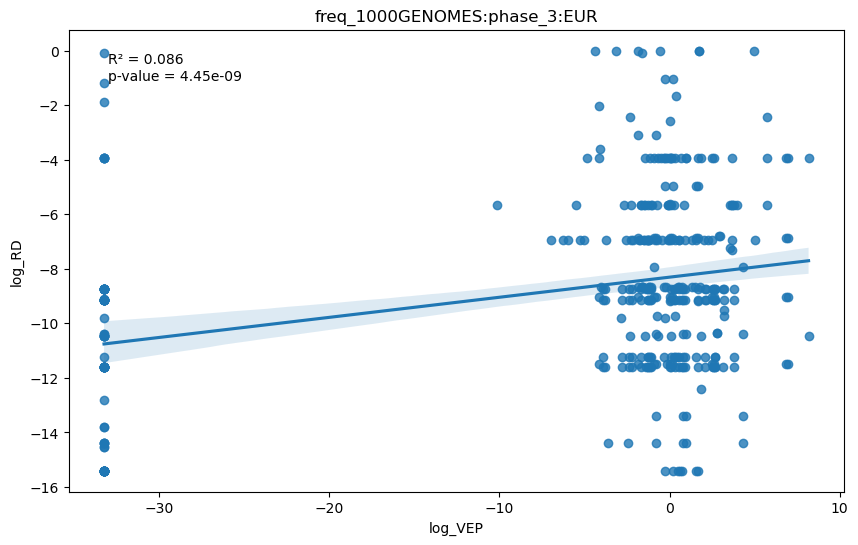

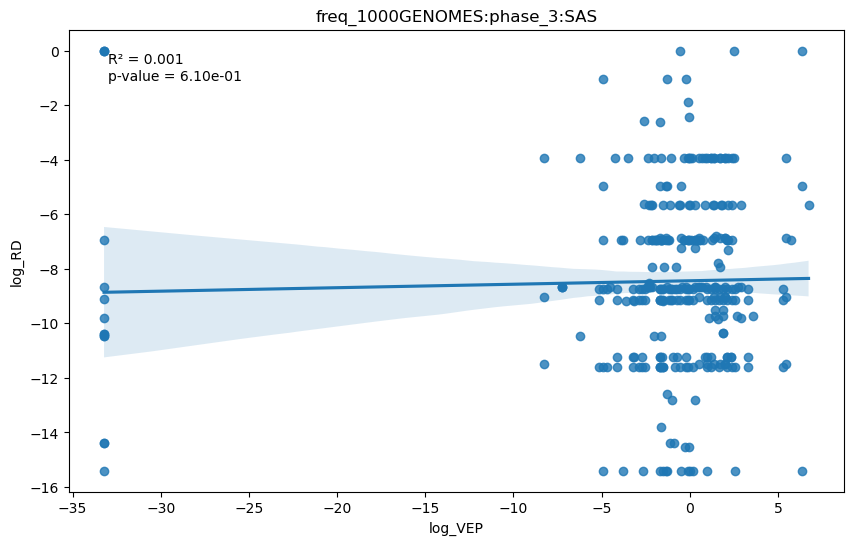

In [156]:
def plot_regression_by_population(data, 
                                  x_col="weighted_var",
                                  y_col="RD",
                                  clinsig_subset=None,
                                  log_columns=True, 
                                  epsilon=1e-10, 
                                  figsize=(10, 6), show_plot=True, log_level='info'):
    """
    Create regression plots for each population in the data.
    
    Args:
        data (pd.DataFrame): DataFrame containing the data to plot
        log_columns (bool): Whether to log transform the VEP and RD columns
        epsilon (float): Small constant to avoid log(0)
        figsize (tuple): Figure size (width, height)
        show_plot (bool): Whether to display the plot
        log_level (str): Logging level ('debug', 'info', 'warning', 'error')
    
    Returns:
        dict: Dictionary containing regression statistics for each population
    """
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np
    from scipy import stats
    import logging
    
    # Configure logging
    logging.basicConfig(level=getattr(logging, log_level.upper()))
    logger = logging.getLogger(__name__)


    results = {}
    
    # Prepare data
    df = data.copy()
    if clinsig_subset is not None:
        df = df[df['clinsig'].isin(clinsig_subset)]
    if log_columns:
        df['log_VEP'] = np.log2(df[x_col] + epsilon)
        df['log_RD'] = np.log2(df[y_col].abs() + epsilon)
        x_col, y_col = 'log_VEP', 'log_RD'
    else:
        x_col, y_col = x_col, y_col
    
    # Process each population
    for pop in df['top_superpop'].unique():
        logger.info(f"Processing population: {pop}")
        
        # Filter and clean data
        df_pop = df[df['top_superpop']==pop]
        mask = ~(np.isnan(df_pop[x_col]) | np.isnan(df_pop[y_col]))
        clean_data = df_pop[mask]
        
        if len(clean_data) == 0:
            logger.warning(f"No valid data points for population {pop}")
            continue
            
        # Calculate regression statistics
        slope, intercept, r_value, p_value, std_err = stats.linregress(clean_data[x_col], 
                                                                       clean_data[y_col])
        r_squared = r_value**2
        
        results[pop] = {
            'slope': slope,
            'intercept': intercept,
            'r_squared': r_squared,
            'p_value': p_value,
            'std_err': std_err
        }
        
        if show_plot:
            plt.figure(figsize=figsize)
            sns.regplot(data=clean_data, x=x_col, y=y_col)
            plt.title(pop)
            plt.text(0.05, 0.95, 
                    f'R² = {r_squared:.3f}\np-value = {p_value:.2e}',
                    transform=plt.gca().transAxes, 
                    verticalalignment='top')
            
            logger.debug(f"Created plot for {pop}")
    
    return results

# Example usage:
results = plot_regression_by_population(rmerge,
                                        x_col="weighted_var_normalized",y_col="RD", log_level='info', 
                                        clinsig_subset=["path","likely_path"])

In [157]:
vep_df["rsID"] = "rs" + vep_df["RS"].fillna(0).round().astype(int).astype(str)
rmerge = vep_df.loc[vep_df["haplotype_sequence_len_pct"]>.50].merge(ukb.groupby("rsID").agg({"RD": "mean"}).reset_index(), 
                              on="rsID", how="inner")

<Axes: xlabel='VEP', ylabel='RD'>

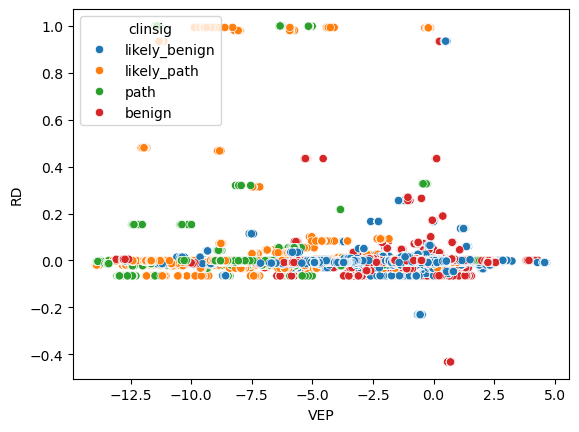

In [112]:
sns.scatterplot(data=rmerge,
                x="VEP",
                y="RD",
                hue="clinsig")

## OpenTargets

In [22]:
ot = pd.read_csv("https://ftp.ebi.ac.uk/pub/databases/opentargets/genetics/latest/OTGenetics_VEP/OTGenetics.tsv.gz",
                 sep="\t", low_memory=False)
print(ot.shape)
ot.head()

(1309708, 8)


,chromosome,position,referenceAllele,alternateAllele,geneId,geneSymbol,geneName,l2g
0,1,832873,A,C,ENSG00000187634,SAMD11,sterile alpha motif domain containing 11,0.532518
1,1,922671,C,T,ENSG00000187634,SAMD11,sterile alpha motif domain containing 11,0.528684
2,1,931558,G,A,ENSG00000187634,SAMD11,sterile alpha motif domain containing 11,0.528684
3,1,946247,G,A,ENSG00000187961,KLHL17,kelch like family member 17,0.586111
4,1,955679,C,T,ENSG00000187961,KLHL17,kelch like family member 17,0.586111


In [27]:
ot = pd.read_parquet("https://ftp.ebi.ac.uk/pub/databases/opentargets/genetics/latest/v2d/part-00000-10068dba-939e-4873-be35-780fc4b12fcc-c000.snappy.parquet")
print(ot.shape)
ot.head()

(225545, 44)


,study_id,lead_chrom,lead_pos,lead_ref,lead_alt,direction,beta,beta_ci_lower,beta_ci_upper,odds_ratio,oddsr_ci_lower,oddsr_ci_upper,pval_mantissa,pval_exponent,pval,ancestry_initial,ancestry_replication,n_cases,n_initial,n_replication,pmid,pub_author,pub_date,pub_journal,pub_title,has_sumstats,num_assoc_loci,source,trait_reported,trait_efos,trait_category,tag_chrom,tag_pos,tag_ref,tag_alt,overall_r2,pics_95perc_credset,AFR_1000G_prop,AMR_1000G_prop,EAS_1000G_prop,EUR_1000G_prop,SAS_1000G_prop,log10_ABF,posterior_prob
0,GCST006585_950,1,1008088,T,C,+,0.735542,0.530600,0.940484,NaN,NaN,NaN,2.00000,-12,2.000000e-12,[European=3200],[],NaN,3200,NaN,PMID:30072576,Emilsson V,2018-08-02,Science,Co-regulatory networks of human serum proteins...,False,1,GCST,"Blood protein levels [ISG15, 14151_4_3]",[EFO_0007937],measurement,1,978812,G,C,0.595703,False,0.0,0.0,0.000000,1.000000,0.0,NaN,NaN
1,NEALE2_20003_1140867876,1,1010747,GT,G,-,NaN,NaN,NaN,0.346424,0.237266,0.505801,4.02417,-8,4.024170e-08,[European=361141],[],491.0,361141,0.0,None,UKB Neale v2,2018-08-01,None,None,True,6,NEALE,Prozac 20mg capsule | treatment/medication code,[EFO_0007010],measurement,1,978812,G,C,NaN,None,NaN,NaN,NaN,NaN,NaN,4.345352,0.00226
2,GCST90087821,1,1009731,C,T,+,0.707278,0.556401,0.858155,NaN,NaN,NaN,4.00000,-20,4.000000e-20,[European=5366],[],NaN,5366,NaN,PMID:35078996,Gudjonsson A,2022-01-25,Nat Commun,A genome-wide association study of serum prote...,False,2,GCST,Serum levels of protein ISG15,[EFO_0007937],measurement,1,978812,G,C,0.579132,False,0.0,0.0,0.000000,1.000000,0.0,NaN,NaN
3,GCST90095130,1,994997,C,T,+,5.840000,3.882404,7.797596,NaN,NaN,NaN,5.00000,-9,5.000000e-09,[European=33748],[],NaN,33748,NaN,PMID:34910505,van der Meer D,2021-12-15,Sci Adv,The genetic architecture of human cortical fol...,False,669,GCST,Vertex-wise cortical surface area,[EFO_0010736],measurement,1,986629,G,A,0.942542,True,0.0,0.0,0.000000,1.000000,0.0,NaN,NaN
4,GCST90018954,1,993036,G,A,+,0.015400,0.010211,0.020589,NaN,NaN,NaN,6.00000,-9,6.000000e-09,"[European=344104, East Asian=133471]",[],NaN,477575,NaN,PMID:34594039,Sakaue S,2021-09-30,Nat Genet,A cross-population atlas of genetic associatio...,False,305,GCST,Gamma glutamyl transpeptidase,[EFO_0004532],measurement,1,986629,G,A,0.910355,True,0.0,0.0,0.279477,0.720523,0.0,NaN,NaN


In [28]:
ot = pd.read_parquet("https://ftp.ebi.ac.uk/pub/databases/opentargets/genetics/latest/variant-index/part-00000-ba6cc0a2-d9cd-414d-97ac-cb51e89946c7-c000.snappy.parquet")
print(ot.shape)
ot.head()

(365652, 14)


,chr_id,position,ref_allele,alt_allele,chr_id_b37,position_b37,rs_id,most_severe_consequence,cadd,af,gene_id_any_distance,gene_id_any,gene_id_prot_coding_distance,gene_id_prot_coding
0,1,30794,G,T,1,30794,rs1311411458,intron_variant,"{'raw': -0.402967, 'phred': 0.177}","{'gnomad_afr': 0.0, 'gnomad_amr': 0.0, 'gnomad...",34625.0,ENSG00000186092,34625.0,ENSG00000186092
1,1,55330,G,A,1,55330,rs185215913,downstream_gene_variant,"{'raw': -0.275244, 'phred': 0.431}","{'gnomad_afr': 0.016711590296495958, 'gnomad_a...",10089.0,ENSG00000186092,10089.0,ENSG00000186092
2,1,57248,C,T,1,57248,rs1249676487,downstream_gene_variant,"{'raw': 0.304146, 'phred': 7.268}","{'gnomad_afr': 0.0, 'gnomad_amr': 0.0, 'gnomad...",8171.0,ENSG00000186092,8171.0,ENSG00000186092
3,1,66381,T,A,1,66381,rs538833530,upstream_gene_variant,"{'raw': -0.101295, 'phred': 1.389}","{'gnomad_afr': 0.15321011673151752, 'gnomad_am...",962.0,ENSG00000186092,962.0,ENSG00000186092
4,1,67631,G,C,1,67631,rs533896527,upstream_gene_variant,"{'raw': -0.632235, 'phred': 0.033}","{'gnomad_afr': 0.041812315138478086, 'gnomad_a...",2212.0,ENSG00000186092,2212.0,ENSG00000186092
